# Airbnb Multi-City Analysis — Notebook 03: Exploratory Data Analysis

**Author:** Data Analyst Team  
**Project:** Airbnb Multi-City Data Analysis  
**Notebook:** 03 - Exploratory Data Analysis  
**Environment:** Python + Jupyter + uv  
**Version:** 1.0  
**Last update:** 2026-04-16

---

## Business Context

After completing data understanding and preprocessing, the project now moves into the exploratory analysis stage.

At this point, the dataset is already standardized and cleaned, which allows a more reliable analysis of:
- market structure,
- price dynamics,
- listing segmentation,
- review behavior,
- and cross-city differences.

## Notebook Objective

The purpose of this notebook is to perform a professional exploratory data analysis (EDA) on the processed Airbnb master dataset.

This notebook focuses on:
- understanding the distribution of core variables,
- identifying differences across cities and room types,
- exploring relationships between variables,
- detecting outliers,
- and generating business-oriented insights that will support dashboard design and hypothesis testing.

In [11]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Environment ready.")
print("EDA notebook initialized.")

Environment ready.
EDA notebook initialized.


## 1. Load Processed Dataset

This notebook uses the clean processed dataset generated in Notebook 02.

In [12]:
# Define input path
input_path = Path("../data/processed/airbnb_clean.csv")

# Check if file exists
if not input_path.exists():
    raise FileNotFoundError(f"File not found: {input_path}")

# Load dataset with error handling
try:
    df = pd.read_csv(input_path, parse_dates=["last_review"])
except Exception as e:
    raise RuntimeError(f"Error loading dataset: {e}")

# Basic validation
if df.empty:
    raise ValueError("Loaded dataset is empty")

# Expected critical columns check
expected_columns = ["price", "room_type", "city", "number_of_reviews"]
missing_cols = [col for col in expected_columns if col not in df.columns]

if missing_cols:
    print(f"Warning: Missing expected columns: {missing_cols}")

# Output confirmation
print(f"Dataset loaded successfully from: {input_path}")
print(f"Shape: {df.shape}")

# Preview
df.head()

Dataset loaded successfully from: ..\data\processed\airbnb_clean.csv
Shape: (220031, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city,has_reviews
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.46,-3.68,private room,60,1,78,2020-09-20,0.58,1.00,180.00,Madrid,1
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40,-3.74,private room,31,4,33,2018-07-15,0.42,2.00,364.00,Madrid,1
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.39,-3.70,entire home/apt,50,15,0,NaT,0.00,7.00,1.00,Madrid,0
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42,-3.71,entire home/apt,92,5,10,2020-03-01,0.13,1.00,72.00,Madrid,1
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.39,-3.69,private room,26,2,149,2020-03-12,1.12,1.00,365.00,Madrid,1


## 2. Initial Dataset Overview

Before starting the exploratory analysis, we perform a quick validation of the processed dataset to confirm its structure and readiness.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 220031 entries, 0 to 220030
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              220031 non-null  int64         
 1   name                            220031 non-null  str           
 2   host_id                         220031 non-null  int64         
 3   host_name                       220031 non-null  str           
 4   neighbourhood_group             68513 non-null   str           
 5   neighbourhood                   220031 non-null  str           
 6   latitude                        220031 non-null  float64       
 7   longitude                       220031 non-null  float64       
 8   room_type                       220031 non-null  str           
 9   price                           220031 non-null  int64         
 10  minimum_nights                  220031 non-null  int64         
 11

In [15]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,"220,031.00",NaN,NaN,NaN,"22,408,312.70","2,539.00","13,383,695.00","22,497,889.00","31,554,452.00","50,955,051.00","11,754,901.81"
name,220031,213148,Unknown,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,"220,031.00",NaN,NaN,NaN,"84,945,277.80","1,944.00","14,396,024.50","46,403,919.00","141,509,678.00","411,720,762.00","88,566,073.77"
host_name,220031,31493,David,1418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,68513,26,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,220031,562,Westminster,9588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,"220,031.00",NaN,NaN,NaN,32.57,-34.14,40.41,40.79,51.50,51.68,30.14
longitude,"220,031.00",NaN,NaN,NaN,16.43,-74.24,-3.71,-0.13,9.20,151.34,76.03
room_type,220031,4,entire home/apt,128154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"220,031.00",NaN,NaN,NaN,917.82,0.00,55.00,99.00,177.00,"1,000,046.00","8,285.22"


## 3. Analytical Focus

The exploratory analysis will concentrate on the variables most relevant for business interpretation and future dashboarding:

- `price`
- `room_type`
- `city`
- `minimum_nights`
- `number_of_reviews`
- `reviews_per_month`
- `availability_365`
- `has_reviews`

The central business variable will be **price**, as it is likely to drive both segmentation and strategic conclusions.

## 4. Univariate Analysis — Price Distribution

We begin with the distribution of price, as it is one of the most important variables in the dataset.

This analysis helps answer:
- Is the distribution symmetric or skewed?
- Are there signs of extreme values?
- Should price transformations be considered later for statistical testing or modeling?

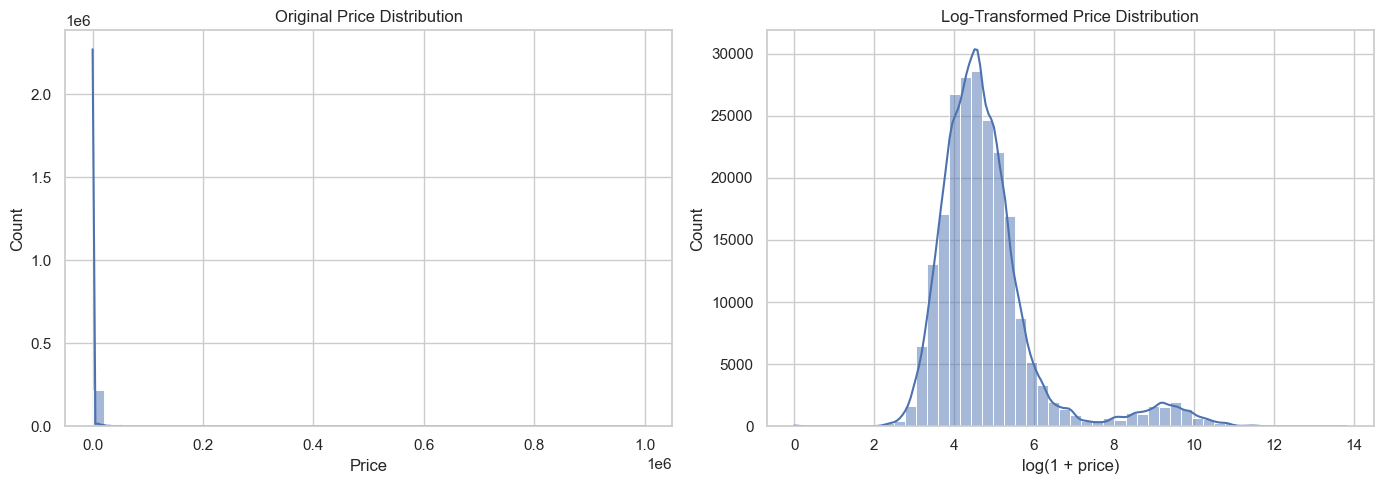

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Original Price Distribution")
axes[0].set_xlabel("Price")

sns.histplot(np.log1p(df["price"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.show()

In [17]:
df["price"].describe()

count     220,031.00
mean          917.82
std         8,285.22
min             0.00
25%            55.00
50%            99.00
75%           177.00
max     1,000,046.00
Name: price, dtype: float64

In [18]:
currency_map = {
    "Madrid": "EUR",
    "Milan": "EUR",
    "London": "GBP",
    "New_York": "USD",
    "Sydney": "AUD",
    "Tokyo": "JPY"
}

exchange_rates = {
    "EUR": 1,
    "GBP": 1.15,
    "USD": 0.92,
    "AUD": 0.60,
    "JPY": 0.006
}

df["currency"] = df["city"].map(currency_map)
df["price_eur"] = df["price"] * df["currency"].map(exchange_rates)

In [23]:
df["price_eur"].describe()

count   220,031.00
mean        132.17
std         268.77
min           0.00
25%          50.60
50%          86.25
75%         143.75
max      14,196.75
Name: price_eur, dtype: float64

### Initial interpretation of price

The price distribution should be reviewed carefully, especially for:
- right skewness,
- concentration in lower ranges,
- and extreme observations that may represent luxury properties or anomalous listings.

This variable will likely require outlier analysis and possibly transformed views in later stages.

## 5. Univariate Analysis — Room Type

In [29]:
room_type_counts = df["room_type"].value_counts(dropna=False).reset_index()
room_type_counts.columns = ["room_type", "count"]
room_type_counts

# Añadir porcentaje
room_type_counts["percentage"] = (
    room_type_counts["count"] / room_type_counts["count"].sum() * 100).round(2)

room_type_counts


,room_type,count,percentage
0,entire home/apt,128154,58.24
1,private room,86512,39.32
2,shared room,4012,1.82
3,hotel room,1353,0.61


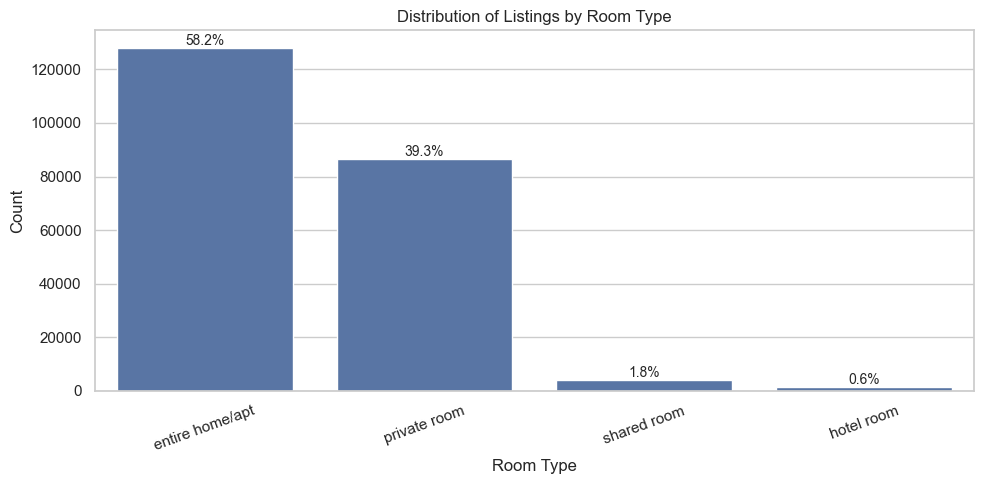

In [30]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="room_type",
    order=df["room_type"].value_counts().index
)

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total) * 100:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Distribution of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

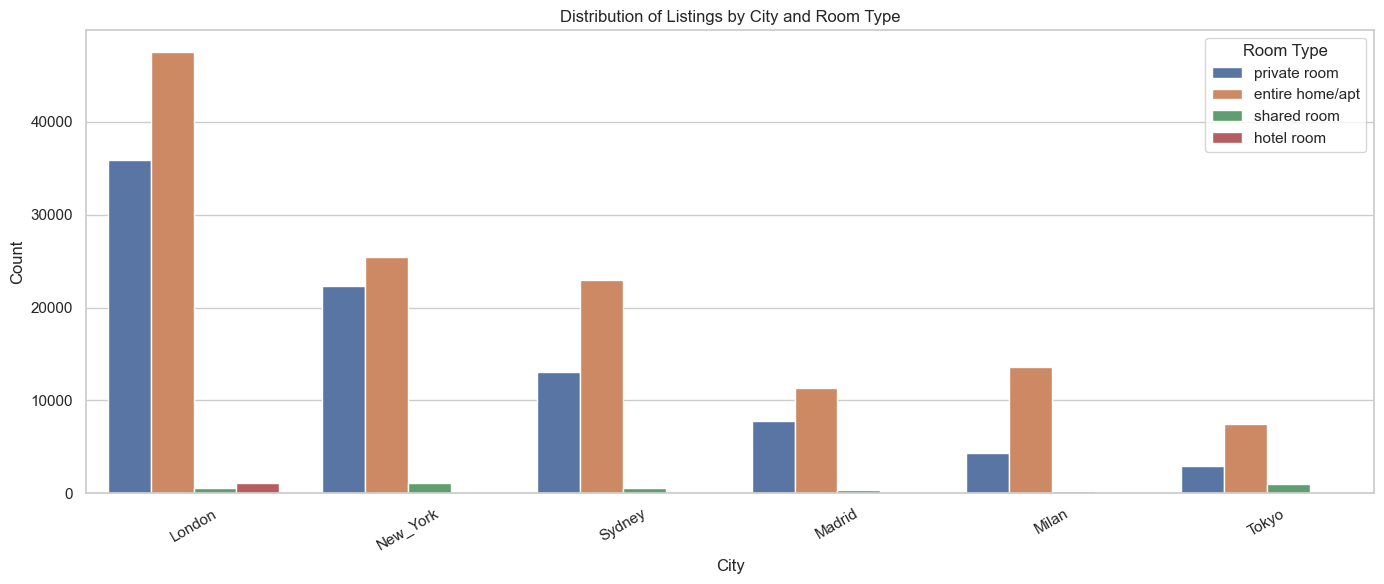

In [31]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x="city",
    hue="room_type",
    order=df["city"].value_counts().index
)

plt.title("Distribution of Listings by City and Room Type")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

### Interpretation

Room type is a core segmentation variable and is expected to explain an important share of price variation across listings.

This variable will later be crossed with city and price to identify structural market differences.

## 6. Univariate Analysis — City Distribution

In [32]:
city_counts = df["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]

city_counts["percentage"] = (
    city_counts["count"] / city_counts["count"].sum() * 100
).round(2)

city_counts

,city,count,percentage
0,London,85068,38.66
1,New_York,48895,22.22
2,Sydney,36662,16.66
3,Madrid,19618,8.92
4,Milan,18322,8.33
5,Tokyo,11466,5.21


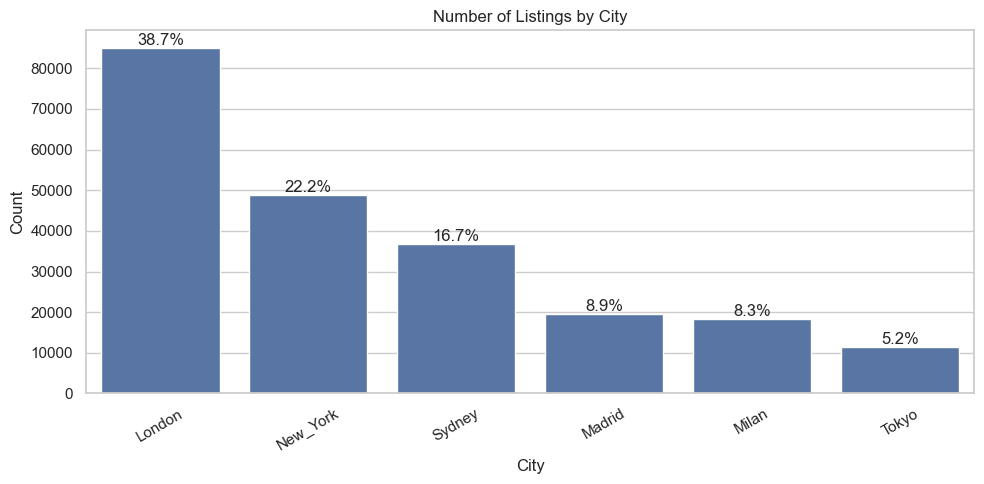

In [33]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="city",
    order=df["city"].value_counts().index
)

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total) * 100:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom"
    )

plt.title("Number of Listings by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretation

The dataset is not evenly balanced across cities.  
This is analytically important, because large differences in representation may influence summary statistics and visual interpretation.

## 7. Univariate Analysis — Reviews and Availability

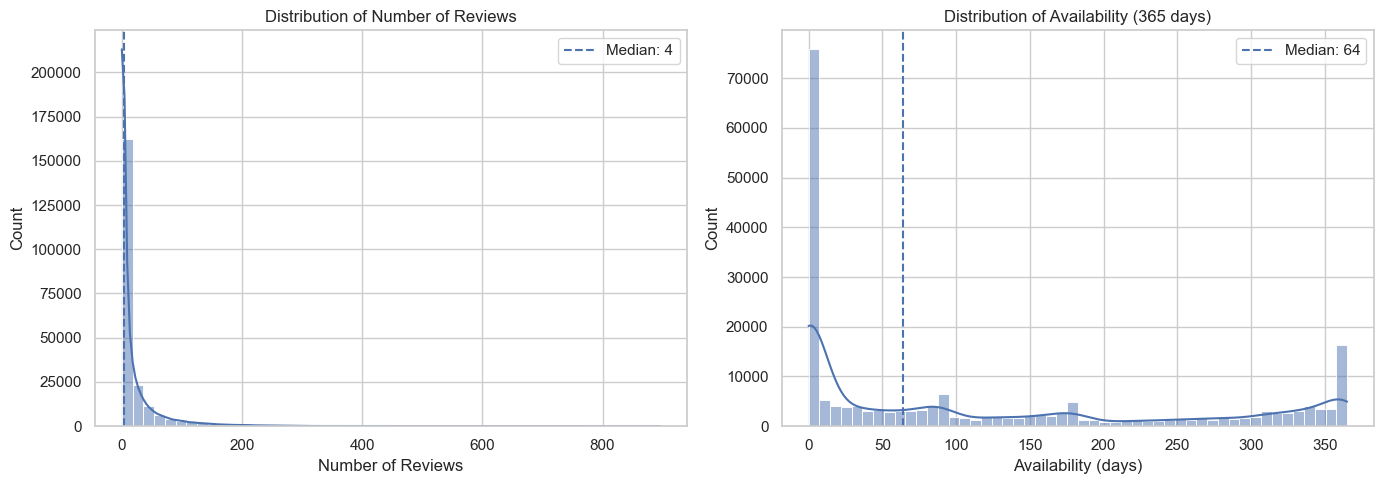

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Number of reviews ---
reviews = df["number_of_reviews"].dropna()
reviews_median = reviews.median()

sns.histplot(reviews, bins=50, kde=True, ax=axes[0])
axes[0].axvline(reviews_median, linestyle="--", linewidth=1.5, label=f"Median: {reviews_median:.0f}")
axes[0].set_title("Distribution of Number of Reviews")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Count")
axes[0].legend()

# --- Availability 365 ---
availability = df["availability_365"].dropna()
availability_median = availability.median()

sns.histplot(availability, bins=50, kde=True, ax=axes[1])
axes[1].axvline(availability_median, linestyle="--", linewidth=1.5, label=f"Median: {availability_median:.0f}")
axes[1].set_title("Distribution of Availability (365 days)")
axes[1].set_xlabel("Availability (days)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

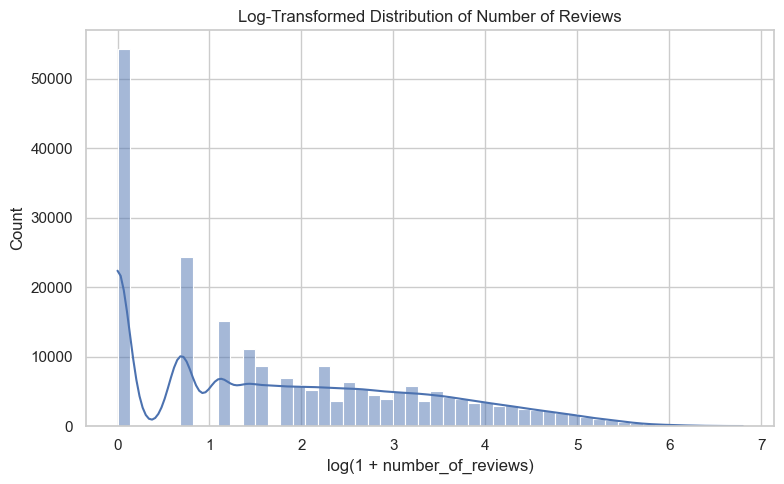

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(np.log1p(df["number_of_reviews"]), bins=50, kde=True)

plt.title("Log-Transformed Distribution of Number of Reviews")
plt.xlabel("log(1 + number_of_reviews)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [37]:
availability_summary = pd.Series({
    "median": df["availability_365"].median(),
    "mean": df["availability_365"].mean(),
    "pct_zero": round((df["availability_365"] == 0).mean() * 100, 2),
    "pct_365": round((df["availability_365"] == 365).mean() * 100, 2)
})

availability_summary

median      64.00
mean       120.33
pct_zero    31.21
pct_365      3.26
dtype: float64

### Interpretation

Review volume and availability may act as indirect signals of listing activity, popularity, or inventory management strategy.

These variables will be especially useful when exploring whether more active or more available listings behave differently in pricing terms.

## 8. Bivariate Analysis — Price by City

In [38]:
city_price_summary = (
    df.groupby("city")["price_eur"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

city_price_summary

,count,mean,median,min,max
city,,,,,
London,85068,140.69,96.60,0.00,"14,196.75"
New_York,48895,140.50,97.52,0.00,"9,200.00"
Madrid,19618,129.27,58.00,0.00,"9,999.00"
Sydney,36662,124.61,81.60,0.00,"8,999.40"
Milan,18322,115.09,73.50,8.00,"11,999.00"
Tokyo,11466,89.91,60.04,0.00,"6,000.28"


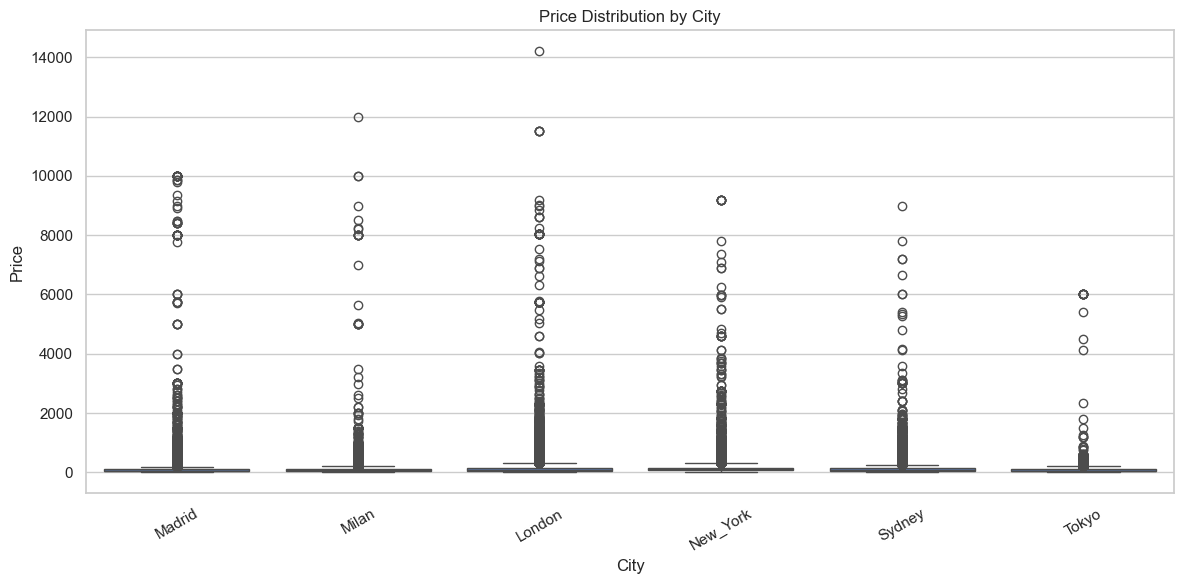

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="city", y="price_eur")
plt.title("Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

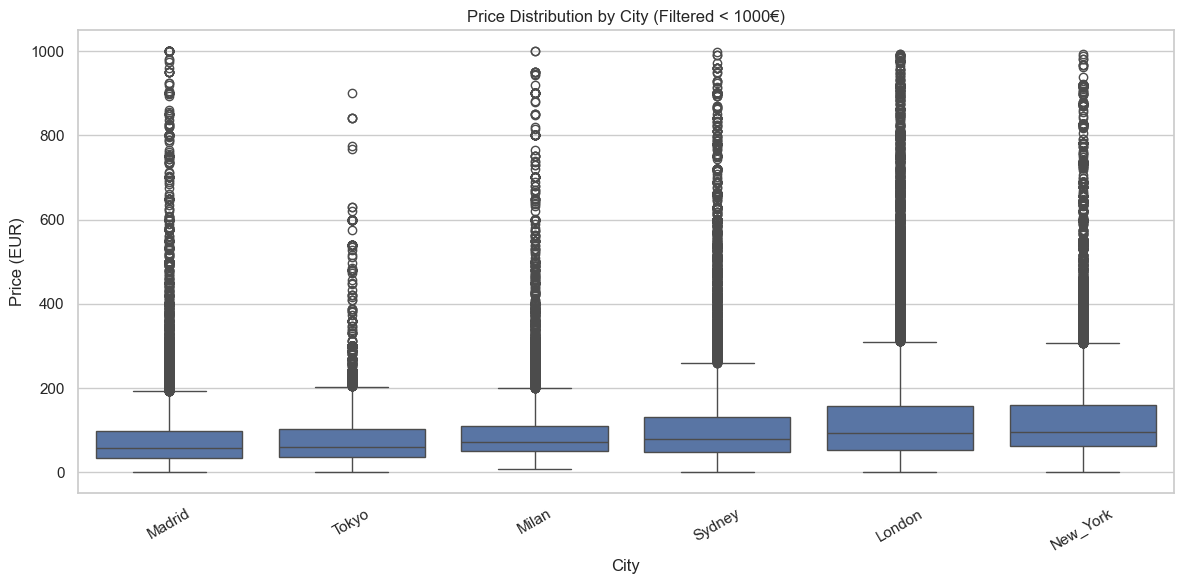

In [ ]:
df_filtered = df[df["price_eur"] < 1000]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_filtered, x="city", y="price_eur")

plt.title("Price Distribution by City (Filtered < 1000€)")
plt.xlabel("City")
plt.ylabel("Price (EUR)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

Comparing cities allows us to identify whether pricing structures differ significantly across markets.

Boxplots are especially useful here because they reveal:
- central tendency,
- dispersion,
- and the presence of extreme values by city.

## 9. Bivariate Analysis — Price by Room Type

In [43]:
df = df[df["price_eur"] > 0]

room_price_summary = (
    df.groupby("room_type")["price_eur"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
)

room_price_summary

,count,mean,median,min,max
room_type,,,,,
hotel room,1345,289.18,155.25,16.10,"11,498.85"
entire home/apt,128139,174.29,119.60,4.60,"14,196.75"
private room,86489,71.16,50.60,1.15,"9,200.00"
shared room,4008,51.22,28.52,3.60,"3,000.00"


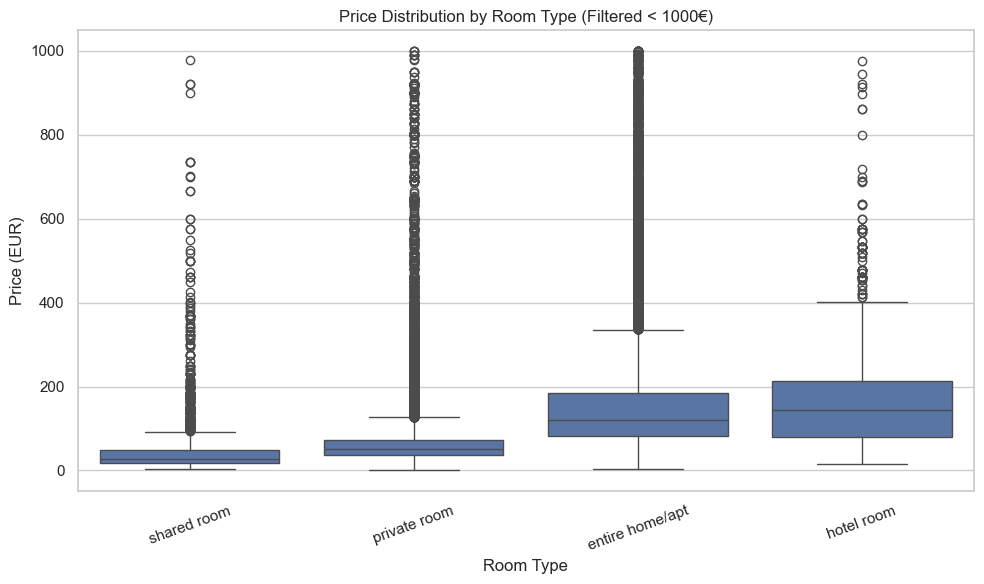

In [46]:
df_filtered = df[df["price_eur"] < 1000]

order = df_filtered.groupby("room_type")["price_eur"].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_filtered,
    x="room_type",
    y="price_eur",
    order=order
)

plt.title("Price Distribution by Room Type (Filtered < 1000€)")
plt.xlabel("Room Type")
plt.ylabel("Price (EUR)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

This comparison is expected to be one of the strongest business insights in the project.

If room type clearly separates price levels, it may become:
- a key dashboard filter,
- a strong explanatory variable in statistical testing,
- and an important predictor in future modeling.

## 10. Bivariate Analysis — Reviews vs Price

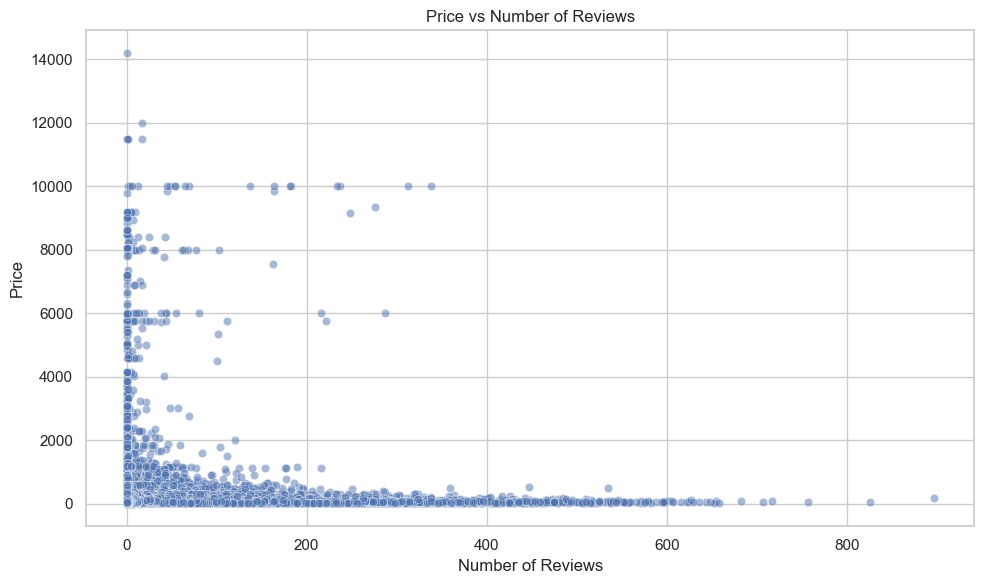

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="number_of_reviews", y="price_eur", alpha=0.5)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

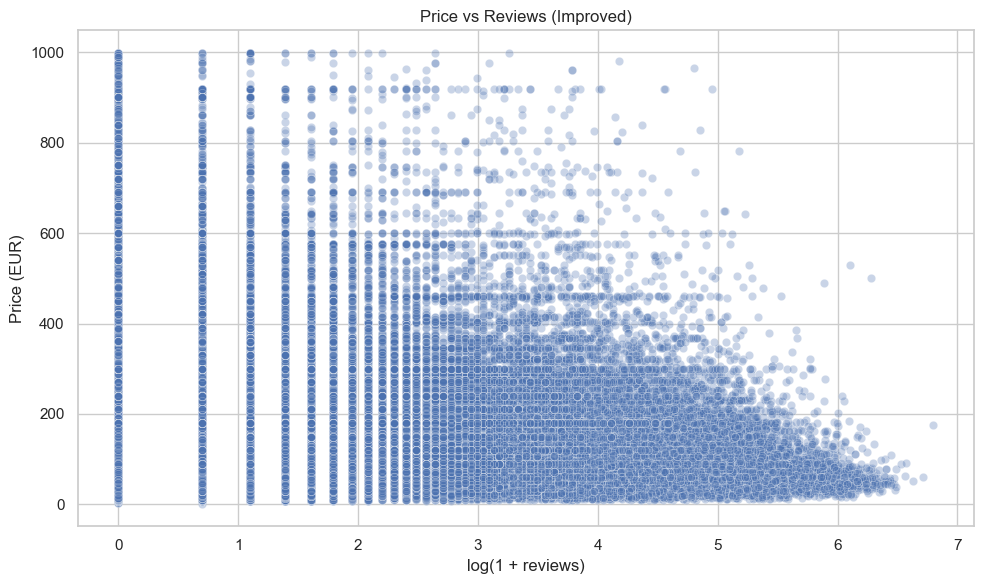

In [50]:
df_scatter = df[df["price_eur"] < 1000]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter,
    x=np.log1p(df_scatter["number_of_reviews"]),
    y="price_eur",
    alpha=0.3
)

plt.title("Price vs Reviews (Improved)")
plt.xlabel("log(1 + reviews)")
plt.ylabel("Price (EUR)")

plt.tight_layout()
plt.show()

In [51]:
df[["price_eur", "number_of_reviews", "reviews_per_month", "minimum_nights", "availability_365"]].corr(numeric_only=True)

,price_eur,number_of_reviews,reviews_per_month,minimum_nights,availability_365
price_eur,1.00,-0.04,-0.05,0.03,0.06
number_of_reviews,-0.04,1.00,0.61,-0.04,0.12
reviews_per_month,-0.05,0.61,1.00,-0.08,0.11
minimum_nights,0.03,-0.04,-0.08,1.00,0.07
availability_365,0.06,0.12,0.11,0.07,1.00


### Interpretation

The relationship between reviews and price is not necessarily linear.  
A visual review, together with correlation analysis, helps assess whether highly reviewed listings also tend to be more expensive, or whether a different market logic is present.

## 11. Bivariate Analysis — Availability vs Price

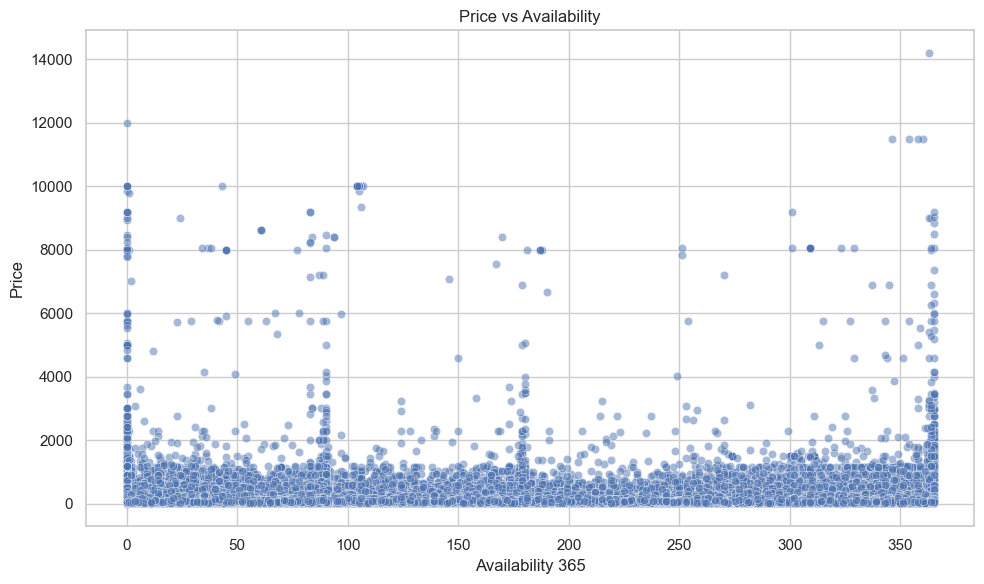

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="availability_365", y="price_eur", alpha=0.5)
plt.title("Price vs Availability")
plt.xlabel("Availability 365")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

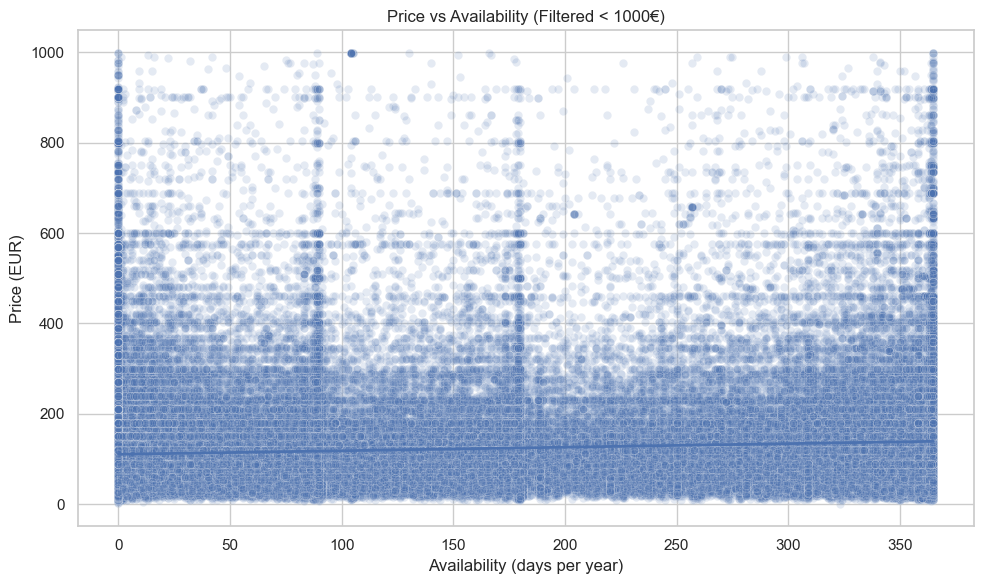

In [56]:
df_scatter = df[df["price_eur"] < 1000].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter,
    x="availability_365",
    y="price_eur",
    alpha=0.15
)

sns.regplot(
    data=df_scatter,
    x="availability_365",
    y="price_eur",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2}
)

plt.title("Price vs Availability (Filtered < 1000€)")
plt.xlabel("Availability (days per year)")
plt.ylabel("Price (EUR)")
plt.tight_layout()
plt.show()

### Interpretation

Availability may reflect different market behaviors:
- high availability may indicate lower occupancy,
- or a deliberate listing strategy,
- while low availability may reflect stronger demand or seasonality.

Its relationship with price should therefore be interpreted with caution and business context.

## 12. Multivariate Analysis — Correlation Matrix

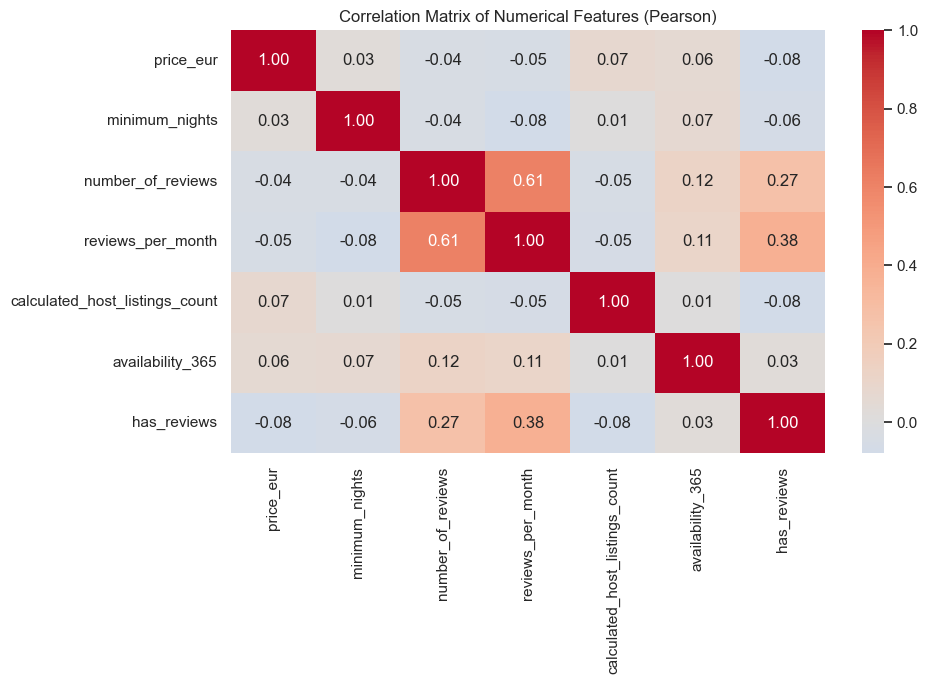

,pearson_corr_with_price
price_eur,1.00
calculated_host_listings_count,0.07
availability_365,0.06
minimum_nights,0.03
number_of_reviews,-0.04
reviews_per_month,-0.05
has_reviews,-0.08


In [61]:
numeric_features = [
    "price_eur",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews"
]

# Pearson correlation
corr_matrix = df[numeric_features].corr(method="pearson", numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features (Pearson)")
plt.tight_layout()
plt.show()

# Focus on correlations with target variable
corr_with_price = (
    corr_matrix["price_eur"]
    .sort_values(ascending=False)
    .to_frame(name="pearson_corr_with_price")
)

corr_with_price

In [63]:
# Añadir valor absoluto para ver importancia real
corr_with_price["abs_corr"] = corr_with_price["pearson_corr_with_price"].abs()

# Ordenar por impacto real
corr_with_price.sort_values("abs_corr", ascending=False)

,pearson_corr_with_price,abs_corr
price_eur,1.00,1.00
has_reviews,-0.08,0.08
calculated_host_listings_count,0.07,0.07
availability_365,0.06,0.06
reviews_per_month,-0.05,0.05
number_of_reviews,-0.04,0.04
minimum_nights,0.03,0.03


In [64]:
# Filtrar precios extremos
df_filtered = df[df["price_eur"] < 1000]

# Correlación en dataset limpio
corr_filtered = df_filtered[numeric_features].corr()

corr_filtered["price_eur"].sort_values(ascending=False)

price_eur                         1.00
calculated_host_listings_count    0.17
availability_365                  0.09
minimum_nights                    0.00
reviews_per_month                -0.09
number_of_reviews                -0.09
has_reviews                      -0.11
Name: price_eur, dtype: float64

In [65]:
# Spearman correlation (no lineal)
corr_spearman = df[numeric_features].corr(method="spearman")

corr_spearman["price_eur"].sort_values(ascending=False)

price_eur                         1.00
minimum_nights                    0.14
availability_365                  0.08
calculated_host_listings_count    0.08
reviews_per_month                -0.07
has_reviews                      -0.07
number_of_reviews                -0.08
Name: price_eur, dtype: float64

### Interpretation

The correlation matrix provides a compact summary of numerical relationships.  
Strong correlations may suggest explanatory connections, while weak correlations may indicate that pricing is driven by more complex or categorical factors.

## 13. Crossed Segmentation — City and Room Type

In [66]:
city_room_summary = (
    df.groupby(["city", "room_type"])["price_eur"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values(by=["city", "mean"], ascending=[True, False])
)

city_room_summary.head(20)

,city,room_type,count,mean,median
1,London,hotel room,1113,267.50,170.20
0,London,entire home/apt,47437,195.43,138.00
2,London,private room,35873,65.82,51.75
3,London,shared room,627,61.46,32.20
5,Madrid,hotel room,158,361.27,91.00
4,Madrid,entire home/apt,11314,161.38,78.00
7,Madrid,shared room,329,83.40,21.00
6,Madrid,private room,7809,80.12,32.00
9,Milan,hotel room,74,461.36,81.50
8,Milan,entire home/apt,13605,120.91,80.00


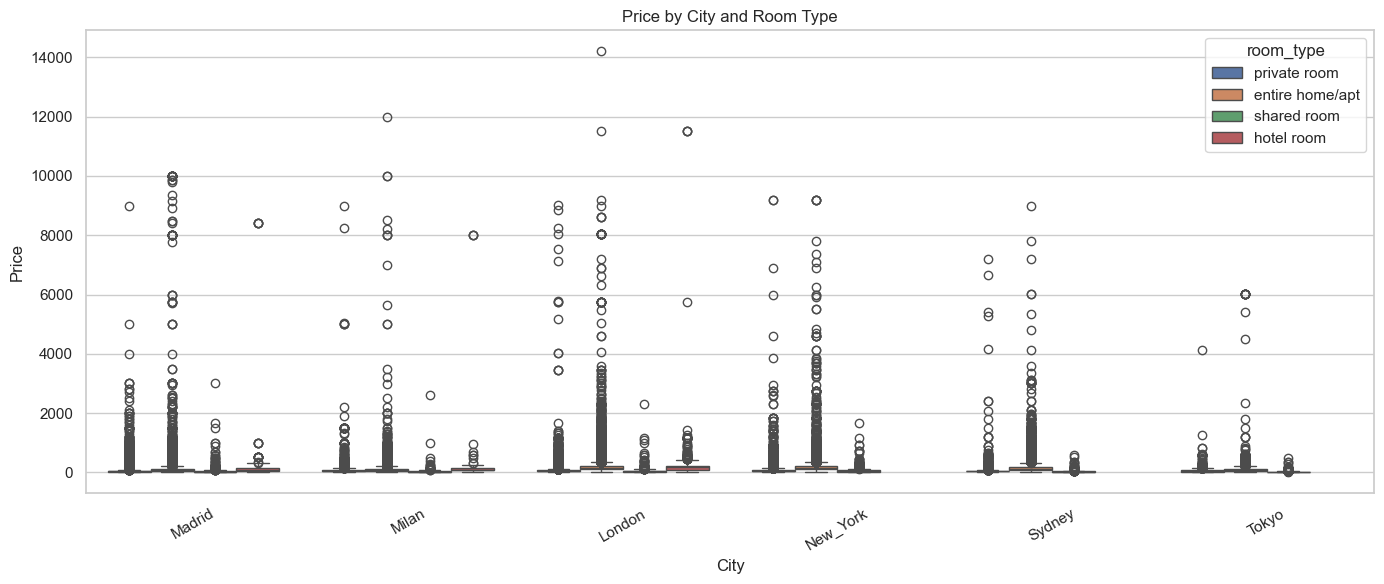

In [67]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="city", y="price_eur", hue="room_type")
plt.title("Price by City and Room Type")
plt.xlabel("City")
plt.ylabel("Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

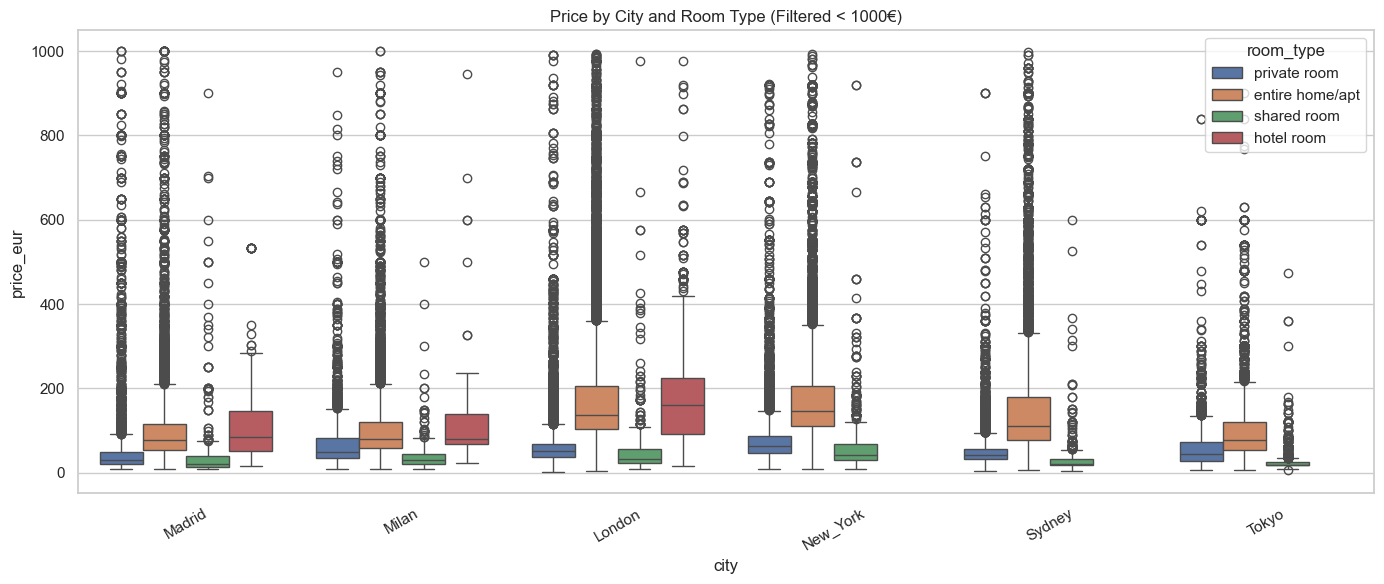

In [68]:
df_filtered = df[df["price_eur"] < 1000]
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_filtered,
    x="city",
    y="price_eur",
    hue="room_type"
)

plt.title("Price by City and Room Type (Filtered < 1000€)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretation

This segmented view is especially useful because it combines the two most relevant business dimensions:
- geography,
- and listing type.

This analysis often reveals whether differences between cities are partly explained by different room type composition.

## 14. Outlier Detection — Price

In [74]:
df_price = df[df["price_eur"] > 0].copy()

q1 = df_price["price_eur"].quantile(0.25)
q3 = df_price["price_eur"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_price_inliers = df_price[
    (df_price["price_eur"] >= lower_bound) & 
    (df_price["price_eur"] <= upper_bound)
].copy()

df_price_outliers = df_price[
    (df_price["price_eur"] < lower_bound) | 
    (df_price["price_eur"] > upper_bound)
].copy()

total = len(df_price)
n_outliers = len(df_price_outliers)
pct_outliers = round((n_outliers / total) * 100, 2)

print("IQR Analysis (Price EUR)")
print("-" * 35)
print(f"Q1 (25%)         : {q1:.2f}")
print(f"Q3 (75%)         : {q3:.2f}")
print(f"IQR              : {iqr:.2f}")
print(f"Lower bound      : {lower_bound:.2f}")
print(f"Upper bound      : {upper_bound:.2f}")
print()
print(f"Total rows       : {total}")
print(f"Outliers         : {n_outliers}")
print(f"Outlier %        : {pct_outliers}%")

IQR Analysis (Price EUR)
-----------------------------------
Q1 (25%)         : 50.60
Q3 (75%)         : 143.75
IQR              : 93.15
Lower bound      : -89.13
Upper bound      : 283.48

Total rows       : 219981
Outliers         : 16253
Outlier %        : 7.39%


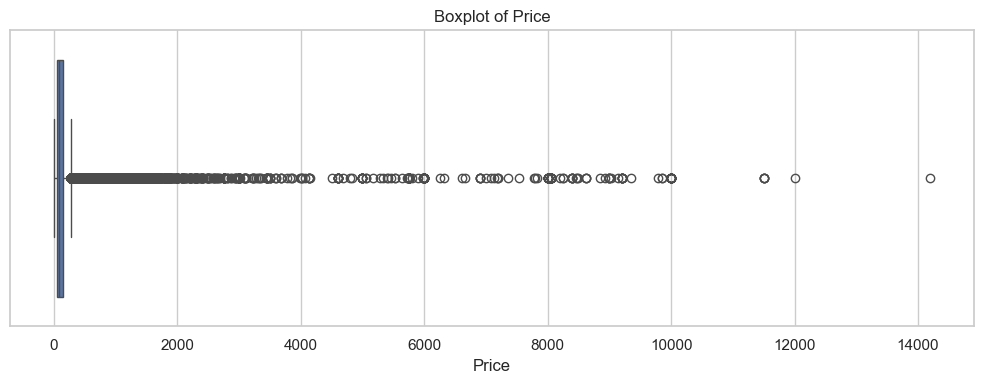

In [75]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["price_eur"])
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

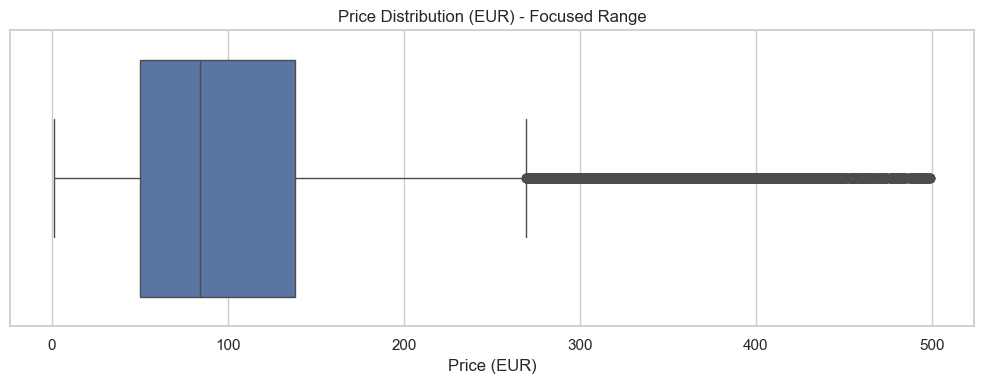

In [77]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[df["price_eur"] < 500]["price_eur"] 
)

plt.title("Price Distribution (EUR) - Focused Range")
plt.xlabel("Price (EUR)")

plt.tight_layout()
plt.show()

In [82]:
outlier_summary = (
    df_price_outliers
    .groupby(["city", "room_type"])
    .agg(
        count=("price_eur", "size"),
        median_price=("price_eur", "median"),
        p90_price=("price_eur", lambda x: x.quantile(0.90)),
        max_price=("price_eur", "max"),
        avg_reviews=("number_of_reviews", "mean")
    )
    .sort_values("count", ascending=False)
)

outlier_summary

count  median_price  p90_price  max_price  \
city     room_type                                                    
London   entire home/apt   6867        391.00     862.50  14,196.75   
New_York entire home/apt   2927        391.00     828.00   9,200.00   
Sydney   entire home/apt   2845        420.00     837.60   8,999.40   
Milan    entire home/apt    768        400.00     900.00  11,999.00   
Madrid   entire home/apt    737        530.00   2,000.00   9,999.00   
         private room       479        500.00   1,099.20   9,000.00   
London   private room       390        426.07   1,150.00   9,029.80   
New_York private room       348        459.54   1,269.60   9,200.00   
Tokyo    entire home/apt    301        300.21     599.77   6,000.28   
London   hotel room         223        460.00   1,150.00  11,498.85   
Milan    private room       142        500.00   1,498.00   8,990.00   
Sydney   private room        84        384.30   1,710.00   7,200.00   
Tokyo    private room        34        509.71     773.89   4,137.05   
Madrid   hotel room          24        532.00   8,399.00   8,399.00   
New_York shared room         23        414.00     920.00   1,656.00   
Madrid   shared room         20        525.00   1,515.00   3,000.00   
London   shared room         16        471.50   1,121.25   2,300.00   
Milan    hotel room          10        650.00   8,000.00   8,000.00   
Sydney   shared room          6        354.00     562.20     599.40   
Milan    shared room          5        500.00   1,960.00   2,600.00   
Tokyo    shared room          4        360.25     439.79     473.87   

                          avg_reviews  
city     room_type                     
London   entire home/apt         8.00  
New_York entire home/apt        15.14  
Sydney   entire home/apt         4.21  
Milan    entire home/apt         8.86  
Madrid   entire home/apt        18.06  
         private room            1.28  
London   private room            5.96  
New_York private room            5.42  
Tokyo    entire home/apt        26.32  
London   hotel room             11.76  
Milan    private room            3.26  
Sydney   private room            2.19  
Tokyo    private room            4.12  
Madrid   hotel room              7.92  
New_York shared room             2.43  
Madrid   shared room             2.25  
London   shared room             2.69  
Milan    hotel room             17.40  
Sydney   shared room             0.00  
Milan    shared room             0.20  
Tokyo    shared room            14.50

### Outlier interpretation

Not all outliers should be treated as errors.

In marketplace data, extreme prices may represent:
- premium or luxury properties,
- exceptional locations,
- or atypical rental conditions.

Therefore, outliers should first be interpreted from a business perspective before deciding whether they should be excluded from specific analyses or modeling steps.

## 15. Optional Log-Scale View of Price

Given the likely right-skewness of the price variable, a log-transformed view can help visualize the distribution more clearly without modifying the base dataset.

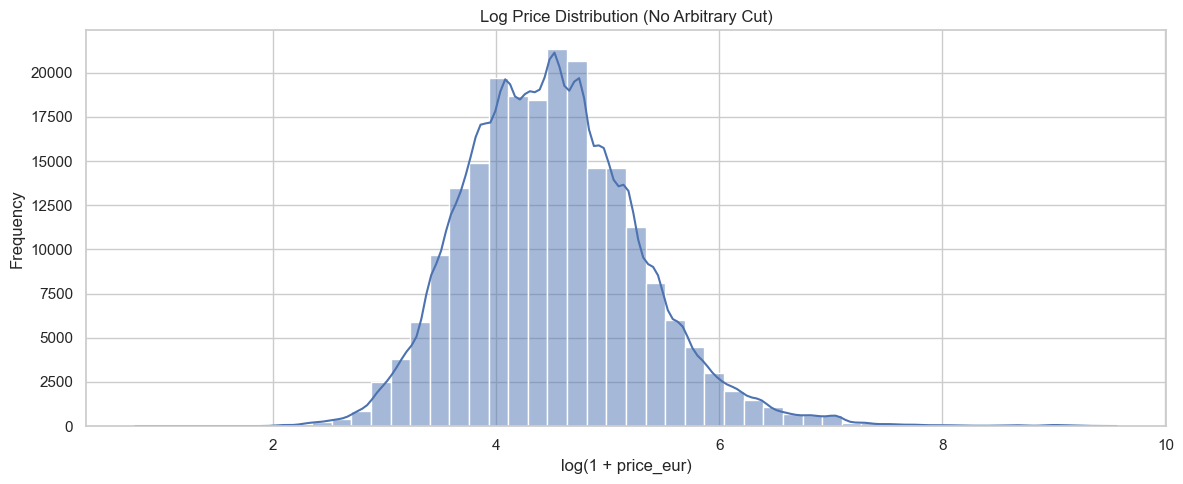

In [87]:
# eliminar valores inválidos
df_clean = df[df["price_eur"] > 0].copy()

# log transform
df_clean["log_price"] = np.log1p(df_clean["price_eur"])

plt.figure(figsize=(12, 5))

sns.histplot(df_clean["log_price"], bins=50, kde=True)

plt.title("Log Price Distribution (No Arbitrary Cut)")
plt.xlabel("log(1 + price_eur)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Why this matters

The log-scale view is useful for interpretation and later modeling decisions, but it is intentionally created here as an **analytical helper** rather than a preprocessing requirement.

## 16. Business Insights Generated in This EDA

At this stage, the exploratory analysis should already start generating business-facing insights.

Examples of potential insights include:
- whether certain cities are structurally more expensive,
- whether room type strongly drives price differentiation,
- whether review-heavy listings follow a different pricing pattern,
- and whether outliers are concentrated in specific segments.

In [88]:
insights_table = pd.DataFrame({
    "insight_area": [
        "Price distribution",
        "City segmentation",
        "Room type segmentation",
        "Outlier behavior",
        "Review behavior"
    ],
    
    "key_insight": [
        "Price shows strong right skew; follows a log-normal distribution with a long tail",
        "London and New York dominate listings and exhibit higher pricing levels",
        "Entire home/apt listings drive the premium segment, significantly higher than private/shared rooms",
        "Outliers are concentrated in entire homes; extreme values likely include anomalies or luxury listings",
        "Weak negative relationship between price and reviews; expensive listings do not necessarily receive more reviews"
    ],
    
    "evidence": [
        "Histogram + log transform revealed symmetric distribution",
        "City-level aggregation showed highest counts and averages in London/New York",
        "Boxplots by room type showed clear price separation",
        "IQR analysis (~7.4% outliers) and extreme values (>10k€) identified",
        "Correlation analysis showed near-zero relationship with price (~ -0.04)"
    ],
    
    "business_impact": [
        "Use log(price) for modeling and pricing strategies",
        "Prioritize high-demand cities for market expansion or investment",
        "Differentiate pricing strategy by room type",
        "Filter or cap extreme values before modeling or reporting",
        "Do not rely on reviews as a pricing driver"
    ],
    
    "confidence": [
        "High",
        "High",
        "High",
        "Medium",
        "Medium"
    ]
})

insights_table

,insight_area,key_insight,evidence,business_impact,confidence
0,Price distribution,Price shows strong right skew; follows a log-n...,Histogram + log transform revealed symmetric d...,Use log(price) for modeling and pricing strate...,High
1,City segmentation,London and New York dominate listings and exhi...,City-level aggregation showed highest counts a...,Prioritize high-demand cities for market expan...,High
2,Room type segmentation,Entire home/apt listings drive the premium seg...,Boxplots by room type showed clear price separ...,Differentiate pricing strategy by room type,High
3,Outlier behavior,Outliers are concentrated in entire homes; ext...,IQR analysis (~7.4% outliers) and extreme valu...,Filter or cap extreme values before modeling o...,Medium
4,Review behavior,Weak negative relationship between price and r...,Correlation analysis showed near-zero relation...,Do not rely on reviews as a pricing driver,Medium


## 17. Executive Summary

This notebook explored the clean Airbnb multi-city dataset from a business and analytical perspective.

### Main contributions
1. Reviewed the distribution of core variables.
2. Confirmed the central importance of price for the project.
3. Compared pricing structures across cities.
4. Evaluated room type as a major segmentation variable.
5. Explored relationships between reviews, availability, and price.
6. Identified and documented price outliers.
7. Generated insights that can directly support hypothesis testing and dashboard design.

The project is now ready to move into formal hypothesis definition and statistical validation.

## 18. Next Steps

The next notebook will formalize business hypotheses and validate them using statistical methods.

That stage will include:
- hypothesis definition,
- test selection,
- statistical interpretation,
- and business-oriented conclusions based on significance testing.

In [89]:
df_kpi = df[df["price_eur"] > 0].copy()

kpi_summary = {
    "total_listings": len(df_kpi),
    "total_cities": df_kpi["city"].nunique(),
    
    "median_price_eur": round(df_kpi["price_eur"].median(), 2),
    "p75_price_eur": round(df_kpi["price_eur"].quantile(0.75), 2),
    
    "avg_reviews": round(df_kpi["number_of_reviews"].mean(), 2),
    "avg_availability": round(df_kpi["availability_365"].mean(), 2),
    
    "outlier_pct": round((df_price_outliers.shape[0] / df_kpi.shape[0]) * 100, 2)
}

kpi_summary

{'total_listings': 219981,
 'total_cities': 6,
 'median_price_eur': np.float64(86.25),
 'p75_price_eur': np.float64(143.75),
 'avg_reviews': np.float64(20.13),
 'avg_availability': np.float64(120.34),
 'outlier_pct': 7.39}

## KPI Snapshot

Before diving into detailed analysis, a quick KPI snapshot helps summarize the overall market represented in the dataset.

In [98]:
# 1. Define output directory
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# 2. Define output path
output_path = output_dir / "airbnb_powerbi.csv"

# 3. Create Power BI dataset
# Keep all columns, but remove invalid prices
df_powerbi = df[df["price_eur"] > 0].copy()

# 4. Reset index for clean export
df_powerbi.reset_index(drop=True, inplace=True)

# 5. Export to CSV
df_powerbi.to_csv(output_path, index=False)

# 6. Validation summary
print("Power BI dataset exported successfully")
print("-" * 40)
print(f"Output path : {output_path}")
print(f"Rows        : {df_powerbi.shape[0]:,}")
print(f"Columns     : {df_powerbi.shape[1]}")
print(f"Min price   : {df_powerbi['price_eur'].min():,.2f} EUR")
print(f"Max price   : {df_powerbi['price_eur'].max():,.2f} EUR")
print(f"Median price: {df_powerbi['price_eur'].median():,.2f} EUR")

Power BI dataset exported successfully
----------------------------------------
Output path : ..\data\processed\airbnb_powerbi.csv
Rows        : 219,981
Columns     : 21
Min price   : 1.15 EUR
Max price   : 14,196.75 EUR
Median price: 86.25 EUR


In [99]:
df.loc[df["price_eur"].idxmax()]

id                                               34521924
name                              Primrose Hill-1st Floor
host_id                                         149362525
host_name                                       Short Let
neighbourhood_group                                   NaN
neighbourhood                                      Camden
latitude                                            51.54
longitude                                           -0.16
room_type                                 entire home/apt
price                                               12345
minimum_nights                                          1
number_of_reviews                                       0
last_review                                           NaT
reviews_per_month                                    0.00
calculated_host_listings_count                      51.00
availability_365                                   363.00
city                                               London
has_reviews   